### Check FEROS images and compare for several days

#### - import packages

In [1]:
%matplotlib inline
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib
import matplotlib.pyplot as plt
import mpl_toolkits
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
from datetime import datetime
from astropy.io import ascii
from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from termcolor import colored
# define axis ranges
xl = 0
xu = 2148
yl = 0
yu = 4096


#### - define what images are selected
#### - write these images names to a new list

In [2]:
from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

path      = '/home/angela/LaSilla/P116/FEROS/'
in_file   = path + 'list.lst'   # list all images

flat_img  = np.genfromtxt(in_file,dtype=np.str_)
num= 0
num_img = 0

keyw_obj  = "OBJECT"                       # object, e.g STD or target name
keyw_ext  = "EXPTIME"
keyw_lamp = "HIERARCH ESO INS CALMIRR2 ID "
select = input("Which object type to you want, eg BIAS, FLAT...:")
print("  ")
print("  ")

lamp  = "LAMP3"

#cal_lamp = "LAMP3"
if select == "FLAT":
    sel_expt_low = 10.00
if select ==  "WAVE":
    sel_expt_low = 40.0

#print("time selected:  ", sel_expt_low)

sel_expt_up  = sel_expt_low + 1.0

out_file = path +str(select)+"_select.lst"



# check if list of selected images exists, if yes delete it
if os.path.exists(out_file):
    os.remove(out_file)
else:
    print(colored('Sorry, I can not remove %s file!' % out_file,'red'))
    print("Create a new one")
    print("                ")
    print("                ")    


for item in flat_img:
    image_file=path+item
#   print(image_file)
    hdu_list = fits.open(image_file)
    header = fits.open(image_file)[0].header
    obj    = header[keyw_obj]
    exptime= header[keyw_ext]
    lam    = header[keyw_lamp]
#    print(image_file,obj)
    if obj == select and exptime >= sel_expt_low and exptime <=sel_expt_up:
#    if obj == select and exptime >= sel_expt_low and exptime <=sel_expt_up:        
        with open(out_file, "a") as text_file:
               print(item, file=text_file)
               num_img = num_img +1               # counts number of flat field image
               print(image_file, exptime)
    num=num+1
print("Number of images: ",num)    
print("Number of selected images: ", num_img)


Which object type to you want, eg BIAS, FLAT...: FLAT


  
  
Sorry, I can not remove /home/angela/LaSilla/P116/FEROS/FLAT_select.lst file!
Create a new one
                
                
/home/angela/LaSilla/P116/FEROS/FEROS.2025-10-08T16:42:45.394.fits 10.0428
/home/angela/LaSilla/P116/FEROS/FEROS.2025-10-09T20:41:22.565.fits 10.0429
/home/angela/LaSilla/P116/FEROS/FEROS.2025-10-12T17:43:32.673.fits 10.0407
/home/angela/LaSilla/P116/FEROS/FEROS.2025-10-15T19:06:09.625.fits 10.0412
/home/angela/LaSilla/P116/FEROS/FEROS.2025-12-17T13:27:24.461.fits 10.0462
/home/angela/LaSilla/P116/FEROS/FEROS.2026-01-19T18:14:28.392.fits 10.0451
/home/angela/LaSilla/P116/FEROS/FEROS.2026-01-22T17:13:07.368.fits 10.0451
Number of images:  25
Number of selected images:  7


### Define fuction plot_feros_data to create a figure with number of subplots

#### - total number of plots: 3 lines with 4 plots each

In [5]:
keyw_ext  = "EXPTIME"

def plot_feros_data(image,plt_num):
    image_file=image
    print(image_file)
    hdu_list = fits.open(image_file)
    header = fits.open(image_file)[0].header
    date_obs  = header[keyw_date] 
    exptime     = header[keyw_ext]
    img_data  = hdu_list[0].data
#    print(img_data.shape)
    line_data = hdu_list[0].data[2094:2095,0:2148]
    hdu_list.info()
    axnum=plt.subplot(3,4,plt_num)
    img_stamp = axnum.imshow((img_data),cmap='hot_r',vmin=-0.01, vmax=600,origin='lower')  
    plt.xlim([1,2148])
    plt.ylim([1,4096])
    plt.text(x_min,4200,date_obs,fontdict=font)
    plt.text(100,3700,str(exptime)+"sec",color='white')
#    plt.xlim([0,500])
#    plt.ylim([0,500])    
    plt.xlabel("pixel", color="black")
    plt.ylabel("pixel",color="black")
    axnum.plot(cut_x,cut_y, color='blue')
    inset_axes_l = inset_axes(axnum,
                              width="30%", # width = 30% of parent_bbox
                              height="20%", # height : 20% of parrent_box
                              loc=1, borderpad=1.5,)
    inset_axes_l.plot(a, line_data[0],c='blue')
    inset_axes_l.tick_params(axis='x', colors='white')
    inset_axes_l.tick_params(axis='y', colors='white')

    plt.xlim([xstart,xstart+60])
    plt.ylim([0,25000])
#    plt.xticks([xstart,xstart+130])

plt.show()


### Creates the plots and the figure

flatfield_comp_2026-04-10.pdf
3
/home/angela/LaSilla/P115/FEROS/FEROS.2022-12-01T18:48:46.424.fits
Filename: /home/angela/LaSilla/P115/FEROS/FEROS.2022-12-01T18:48:46.424.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     504   (2148, 4096)   uint16   
/home/angela/LaSilla/P115/FEROS/FEROS.2025-04-29T19:10:20.270.fits
Filename: /home/angela/LaSilla/P115/FEROS/FEROS.2025-04-29T19:10:20.270.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     504   (2148, 4096)   uint16   
/home/angela/LaSilla/P115/FEROS/FEROS.2025-05-29T19:05:03.464.fits
Filename: /home/angela/LaSilla/P115/FEROS/FEROS.2025-05-29T19:05:03.464.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     504   (2148, 4096)   uint16   
/home/angela/LaSilla/P115/FEROS/FEROS.2025-06-11T16:28:22.339.fits
Filename: /home/angela/LaSilla/P115/FEROS/FEROS.2025-06-11T16:28:22.339.fits
No.  

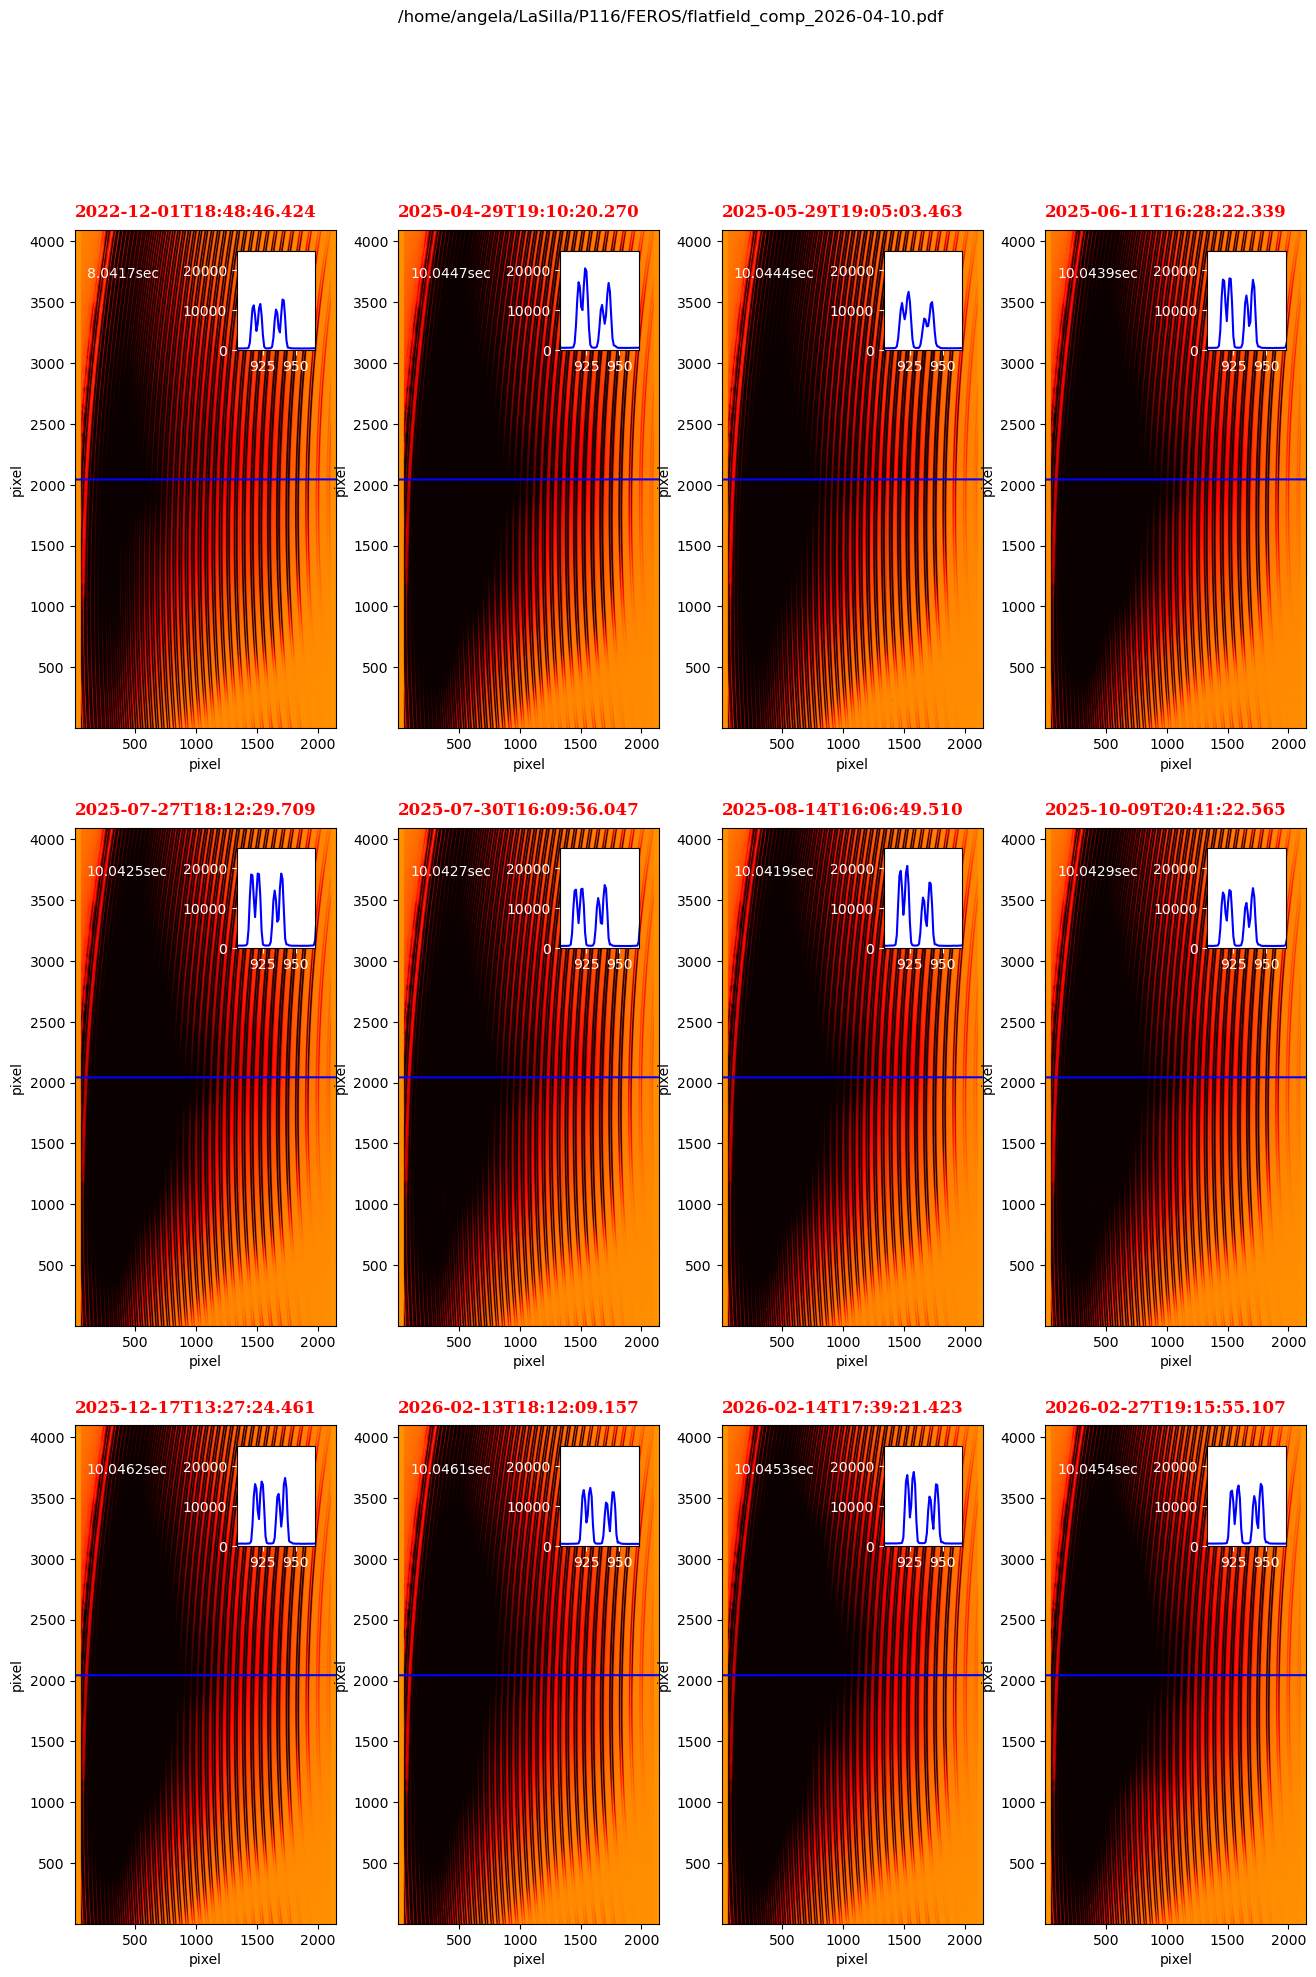

In [6]:
path      = '/home/angela/LaSilla/P116/FEROS/'
in_file   = path + 'FF-input.lst'   # list all bias frames

flat_img  = np.genfromtxt(in_file,dtype=np.str_)

date      = str(datetime.today().strftime('%Y-%m-%d'))

output='flatfield_comp_' +date +'.pdf'
print(output)

matplotlib.rcParams['figure.figsize'] = [16,22]
#plt.figure()
num=12
lines= math.ceil(num/4)
fig,axnum = plt.subplots(lines,4)
#fig, ax1 = plt.subplots(lines,4)

font = {'family': 'serif',
        'color':  'red',
        'weight': 'bold',
        'size': 12,
        }
    
print(lines)
y_coo= 2043
xstart=905
plot_num = 1
x_min =  0
x_max =  2196
y_min =  y_coo-600
y_max =  y_coo+600
lines= math.ceil(num/4)
keyw_date  = "DATE-OBS"
cut_x= [x_min,x_max]
cut_y= [y_coo,y_coo+1]

a=np.arange(0,2148,1)
plot_num=1



for item in flat_img:
    header      = fits.open(item)[0].header
#    print(item)
    plot_feros_data(item,plot_num)
    plot_num=plot_num+1

    
fig.suptitle(path+output)    
    
plt.savefig(path+output)
plt.show()
plt.close()   


### Read 4 images to check line positions
#### * includes the whole path in case data from differen periods are used

In [20]:
path_a      = '/home/angela/LaSilla/P116/FEROS/'
output=   path_a + "wave_comparison_"+ date+"_a.pdf"

date      = str(datetime.today().strftime('%Y-%m-%d'))

in_file   = path + 'WAVE_select.lst'   # list all bias frames

wave_img  = np.genfromtxt(in_file,dtype=np.str_)

#print(wave_img)
img_a = wave_img[0]
img_b = wave_img[1]
img_c = wave_img[2]
img_d = wave_img[3]
print(img_a)
print(img_b)
print(img_c)
print(img_d)

/home/angela/LaSilla/P115/FEROS/FEROS.2025-07-27T19:18:57.672.fits
/home/angela/LaSilla/P116/FEROS/FEROS.2026-02-13T19:20:48.124.fits
/home/angela/LaSilla/P116/FEROS/FEROS.2026-03-25T19:51:02.713.fits
/home/angela/LaSilla/P116/FEROS/FEROS.2026-04-07T19:51:51.650.fits


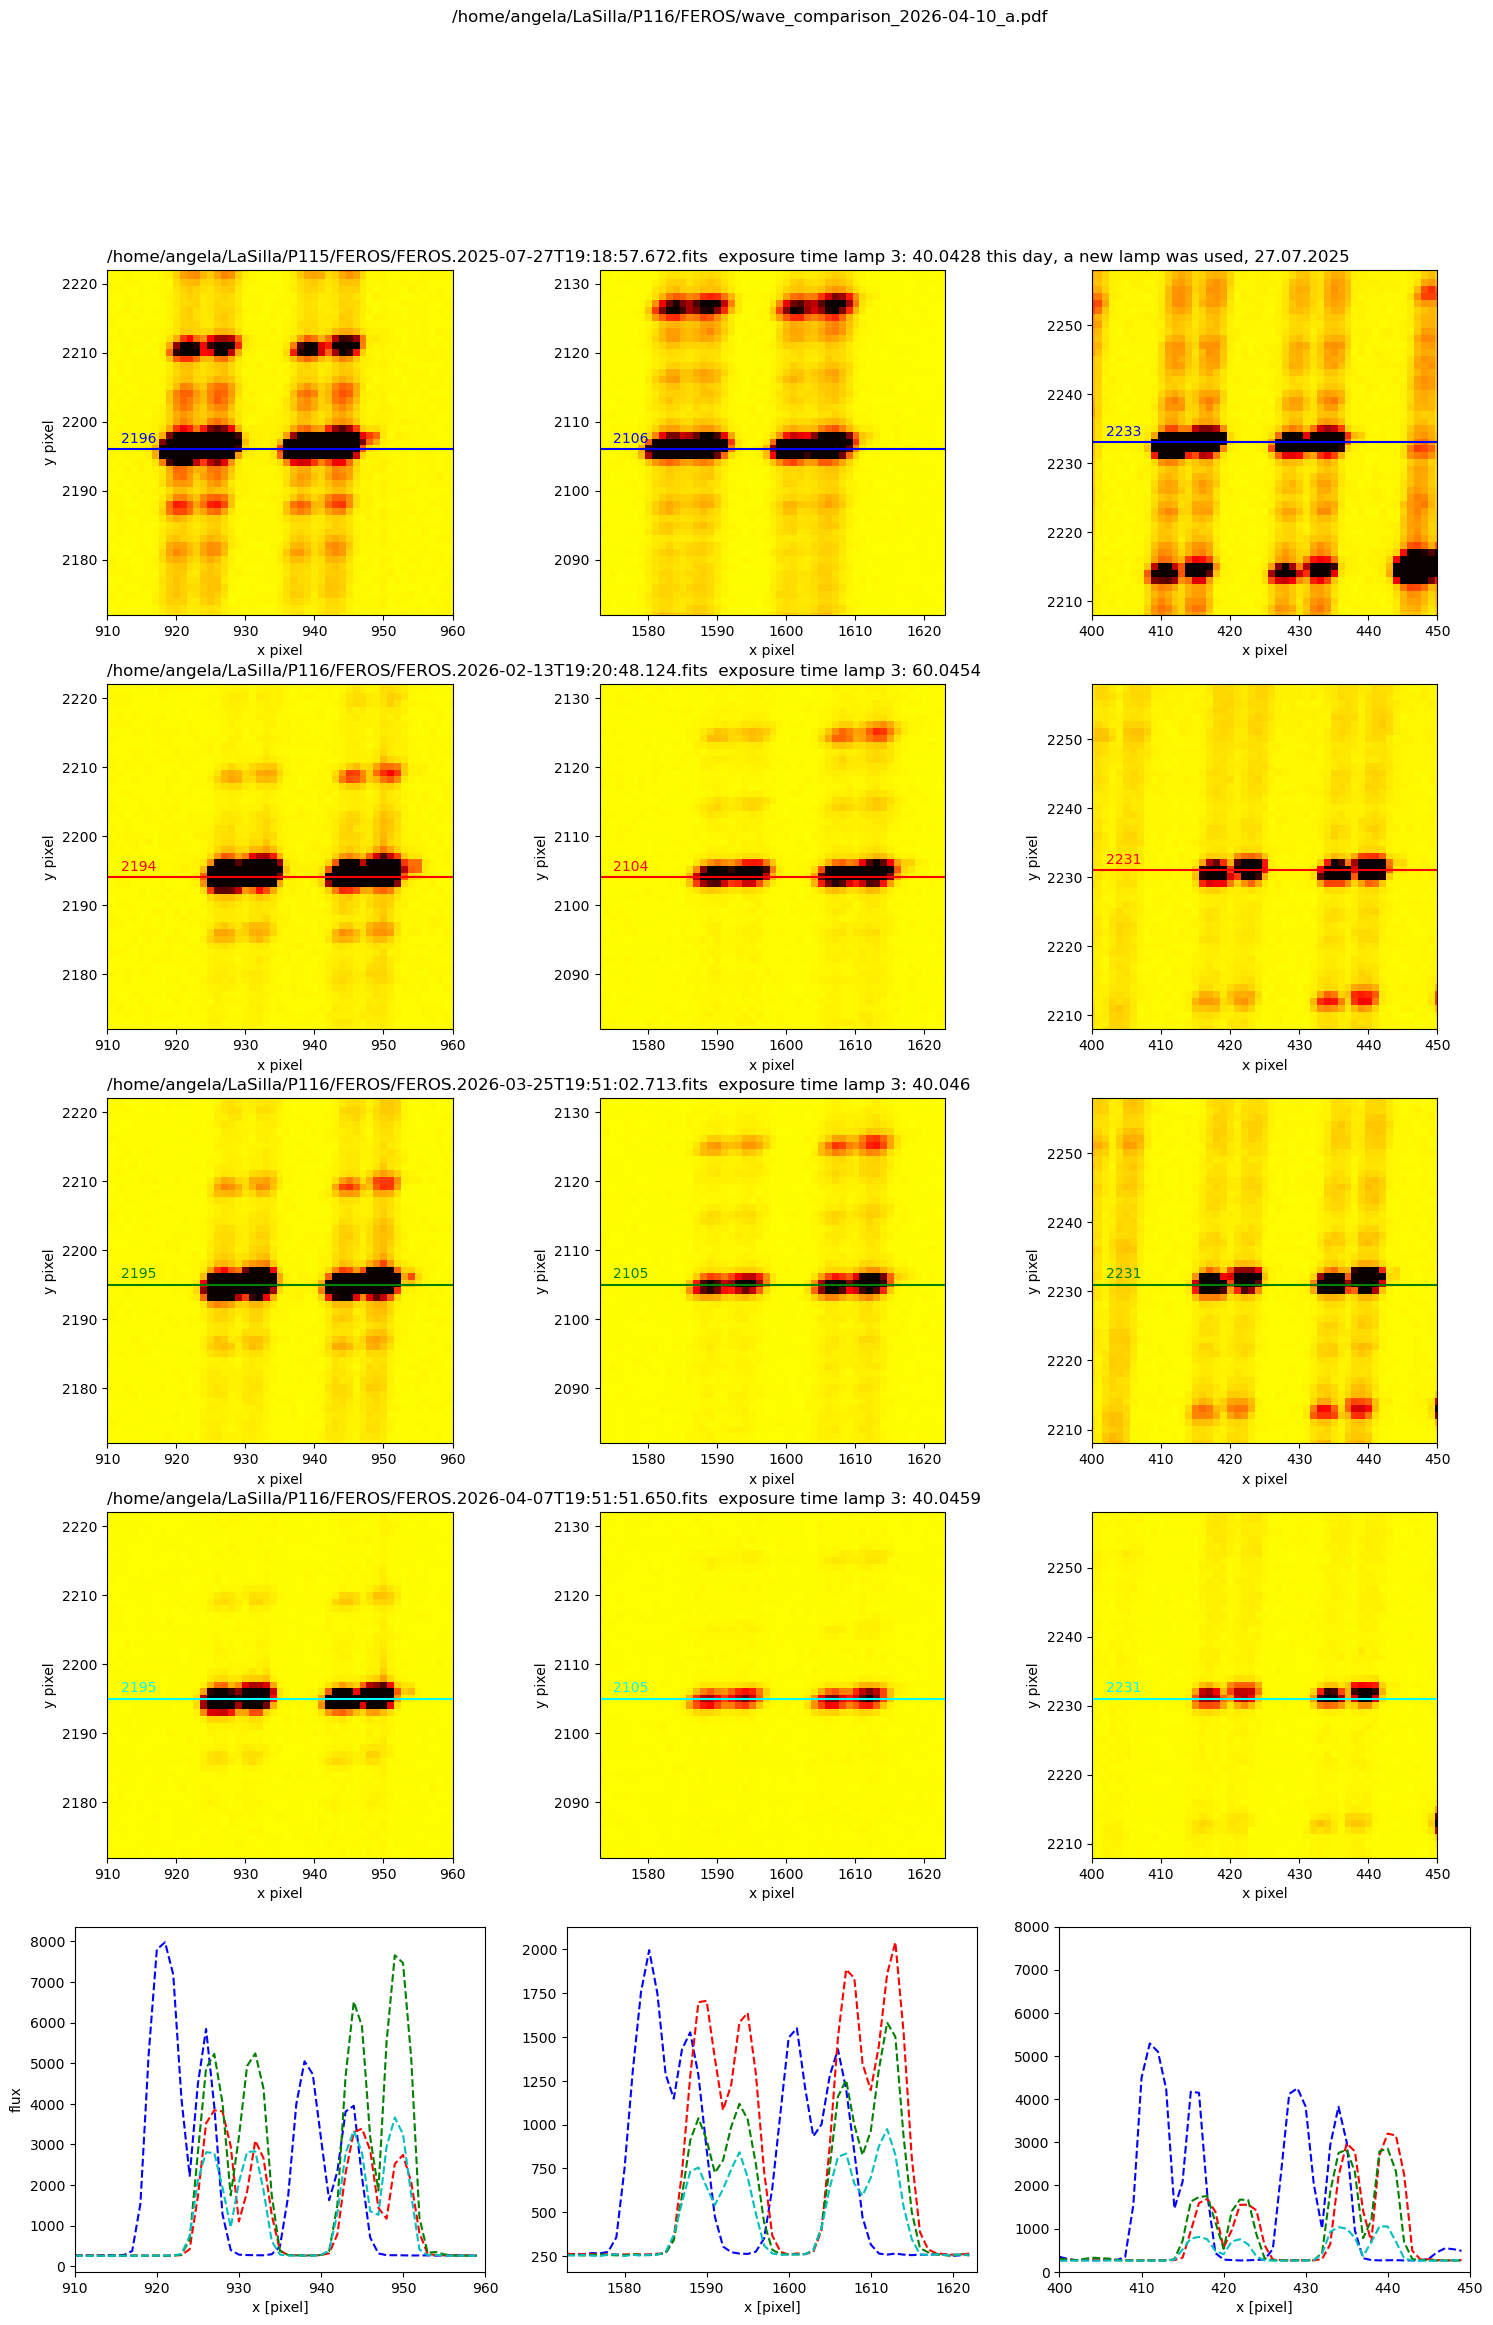

In [21]:
matplotlib.rcParams['figure.figsize'] = [16,29]
keyw_ext  = "EXPTIME"
delta  =  25

xstart_1  = 910 
xend_1    = xstart_1+2*delta
ystart_1  = 2197 - delta
yend_1    = ystart_1+2*delta


xstart_2  = 1573
xend_2    = xstart_2+2*delta
ystart_2  = 2107- delta
yend_2    = ystart_2 + 2*delta

xstart_3  =  400
xend_3    = xstart_3 + 2*delta
ystart_3  = 2233- delta
yend_3    = ystart_3 + 2*delta

b1 = np.arange(xstart_1,xend_1,1)
b2 = np.arange(xstart_2,xend_2,1)
b3 = np.arange(xstart_3,xend_3,1)

fig,axnum = plt.subplots(5, 3, figsize=(18,26))

fig.suptitle(output) 
vmax=1000
vmin = -0.01

# Date 1

plt.subplot(5,3,1)
line = 2196
img         = img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data

line_data_1a = hdu_list[0].data[line-1:line+2,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='blue')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
#titel = img_a +"  exposure time lamp 3: " + str(exptime) + " this day, both fibers had a good rms from the pipeline"
titel = img_a +"  exposure time lamp 3: " + str(exptime)+ " this day, a new lamp was used, 27.07.2025"

plt.title(titel,loc='left')
#plt.text(xstart_1,yend_1+15,"Reference, both fibers with good RMS",color='darkred')
#plt.text(xstart_1,yend_1+10,"ThAr (lamp 3) changed on 12.02.2025",color='darkblue')
plt.text(xstart_1+2,line+1,line,color='blue')

plt.subplot(5,3,2)
line= 2106
line_data_1b = hdu_list[0].data[line-1:line+2,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='blue')
plt.xlabel('x pixel')
plt.text(xstart_2+2,line+1,line,color='blue')

plt.subplot(5,3,3)
line= 2233
line_data_1c = hdu_list[0].data[line-1:line+2,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='blue')
plt.xlabel('x pixel')
plt.text(xstart_3+2,line+1,line,color='blue')

# Date 2

plt.subplot(5,3,4)
line= 2194
img         = img_b
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data
line_data_2a = hdu_list[0].data[line-1:line+2,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='red')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
#titel = img_b +"  exposure time lamp 3: " + str(exptime)
titel = img_b +"  exposure time lamp 3: " + str(exptime) 
plt.title(titel,loc='left')
plt.text(xstart_1+2,line+1,line,color='red')


plt.subplot(5,3,5)
line= 2104

line_data_2b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='red')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(xstart_2+2,line+1,line,color='red')

plt.subplot(5,3,6)
line= 2231
line_data_2c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='red')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(xstart_3+2,line+1,line,color='red')


# Date 3

plt.subplot(5,3,7)
line= 2195
img         = img_c
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data
#line_data_a = hdu_list[0].data[line-1:line,xstart:xend]
line_data_3a = hdu_list[0].data[line:line+1,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])

plt.plot([xstart_1,xend_1],[line,line], color='green')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
titel = img_c +"  exposure time lamp 3: " + str(exptime) 
plt.title(titel,loc='left')
plt.text(xstart_1+2,line+1,line,color='green')

plt.subplot(5,3,8)
line= 2105
line_data_3b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='green')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(xstart_2+2,line+1,line,color='green')

plt.subplot(5,3,9)
line= 2231
line_data_3c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='green')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(xstart_3+2,line+1,line,color='green')


# Date 4

plt.subplot(5,3,10)
line= 2195
img         = img_d
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
exptime     = header[keyw_ext]
img_data    = hdu_list[0].data
#line_data_a = hdu_list[0].data[line-1:line,xstart:xend]
line_data_4a = hdu_list[0].data[line:line+1,xstart_1:xend_1]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])
plt.plot([xstart_1,xend_1],[line,line], color='cyan')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
titel = img_d + "  exposure time lamp 3: "+str(exptime) 
plt.title(titel,loc='left')
plt.text(xstart_1+2,line+1,line,color='cyan')

plt.subplot(5,3,11)
line= 2105
line_data_4b = hdu_list[0].data[line:line+1,xstart_2:xend_2]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_2,xend_2])
plt.ylim([ystart_2,yend_2])
plt.plot([xstart_2,xend_2],[line,line], color='cyan')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(xstart_2+2,line+1,line,color='cyan')

plt.subplot(5,3,12)
line= 2231
line_data_4c = hdu_list[0].data[line:line+1,xstart_3:xend_3]
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_3,xend_3])
plt.ylim([ystart_3,yend_3])
plt.plot([xstart_3,xend_3],[line,line], color='cyan')
plt.xlabel('x pixel')
plt.ylabel('y pixel')
plt.text(xstart_3+2,line+1,line,color='cyan')



plt.subplot(5,3,13)
plt.plot(b1, line_data_1a[0], 'b--')
plt.plot(b1, line_data_2a[0], 'r--')
plt.plot(b1, line_data_3a[0], 'g--')
plt.plot(b1, line_data_4a[0], 'c--')

plt.xlim([xstart_1,xend_1])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')
plt.ylabel('flux')


plt.subplot(5,3,14)
plt.plot(b2, line_data_1b[0], 'b--')
plt.plot(b2, line_data_2b[0], 'r--')
plt.plot(b2, line_data_3b[0], 'g--')
plt.plot(b2, line_data_4b[0], 'c--')

plt.xlim([xstart_2,xend_2])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')


plt.subplot(5,3,15)
plt.plot(b3, line_data_1c[0], 'b--')
plt.plot(b3, line_data_2c[0], 'r--')
plt.plot(b3, line_data_3c[0], 'g--')
plt.plot(b3, line_data_4c[0], 'c--')

plt.xlim([xstart_3,xend_3])
plt.ylim([0,8000])
print('            ')
print('            ')
print('            ')

plt.xlabel('x [pixel]')


plt.savefig(output)
plt.show()
plt.close()   



### Try to fit the line

In [18]:
%matplotlib tk
import matplotlib.image as mpimg
line = 2197
img         = path + img_a
hdu_list    = fits.open(img)
header      = fits.open(img)[0].header
data        = hdu_list[0].data

data_1 = hdu_list[0].data[line-10:line+10,xstart_1:xend_1]

def mouse_event(event):
    print('x: {} and y: {}'.format(event.xdata, event.ydata))

fig = plt.figure()
cid = fig.canvas.mpl_connect('button_press_event', mouse_event)
plt.imshow(img_data, cmap='hot_r',vmin=vmin, vmax=vmax,origin='lower')
plt.xlim([xstart_1,xend_1])
plt.ylim([ystart_1,yend_1])

(2167.0, 2227.0)

x: 920.1290322580645 and y: 2195.784758064516
x: 925.258064516129 and y: 2196.3170161290323
x: 937.6451612903227 and y: 2196.0750806451615
x: 942.7741935483872 and y: 2196.6073387096776
x: 912.0967741935484 and y: 2195.300887096774
x: 951.6290322580645 and y: 2197.67185483871


In [7]:
path      = '/home/angela/LaSilla/P114/FEROS/2024_11_05/'
in_file   = path + 'TauCeti.lst'   # list all bias frames

img       = np.genfromtxt(in_file,dtype=np.str_)

date      = str(datetime.today().strftime('%Y-%m-%d'))

output='TauCeti_comparison_' +date +'.pdf'
print(output)

matplotlib.rcParams['figure.figsize'] = [16,22]
#plt.figure()
num = len(flat_img)
print(num)
num_x = 3
num_y= math.ceil(num / num_x)
print(num_y)

# Check that the image is not using the Fabry-Perot
check_lamp ="HIERARCH ESO INS CALMIRR2 ID = "
val_type = image_header[check_lamp]

for item in flat_img:
#    print(item)
    plot_feros_data(item,plot_num)
    plot_num=plot_num+1


if val_type == "LAMP3":
    print(


TauCeti_comparison_2024-11-21.pdf
11
4


### Compare raw spectra from different nights for the same target
#### in tis case either RV standart or science data

In [64]:
path     = "/home/angela/LaSilla/P114/Costa/"
target   ="HD95456"
img_a =   "FEROS.2023-03-04T05:57:49.086.fits"
img_b =   "FEROS.2024-01-13T07:47:15.531.fits"
img_c =   "FEROS.2025-03-20T02:26:39.647.fits"



output=   path + target + ".pdf"